In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv


Baris code di atas merupakan proses import libarary yang berguna untuk pemrosesan citra dan 
visualisasi data. Library tersebut antara lain, numpy yang digunakan untuk manipulasi data 
array multidimensi, pemerosesan citra seperti transformasi, filtering dan analisis statistik. 
Yang kedua ada matplotlib yang digunakan untuk visualisasi data dalam berbagai format. Yang 
ketiga ada Open CV yang berfungsi untuk membaca dan memuat gambar.

In [2]:
image_a = plt.imread("assets/buggy1.png")
image_b = plt.imread("assets/buggy2.png")
image_c = plt.imread("assets/buggy3.png")
image_d = plt.imread("assets/buggy4.png")

Baris code di atas digunakan untuk memuat gambar yang jumlahnya 4 buah telah disediakan. Fungsi imread() digunakan untuk mengubah gambar ke dalam bentuk array 

Baris kode di bawah digunakan untuk menampilkan empat buah gambar dalam satu kanvas menggunakan fungsi subplot dari matplotlib, yang masing-masing diberi judul dan tanpa menampilkan sumbu koordinat:

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

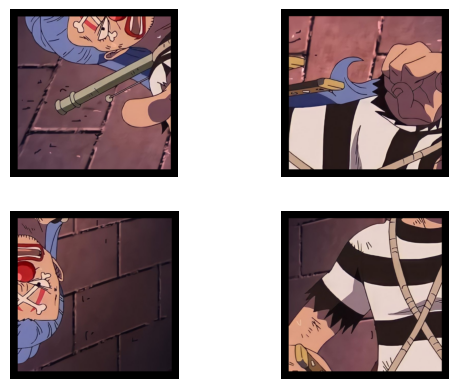

In [3]:
plt.subplot(2, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(image_c)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(image_d)
plt.axis('off')


In [4]:
gray_a = cv.cvtColor(image_a, cv.COLOR_BGR2GRAY)
gray_b = cv.cvtColor(image_b, cv.COLOR_BGR2GRAY)
gray_c = cv.cvtColor(image_c, cv.COLOR_BGR2GRAY)
gray_d = cv.cvtColor(image_d, cv.COLOR_BGR2GRAY)

Baris code di atas ini digunakan untuk mengubah gambar ke dalam skala grayscale. 

Baris code di bawah ini digunakan untuk menampilkan empat buah gambar dalam satu kanvas menggunakan fungsi subplot dari matplotlib gambar hasil konversi ke dalam skala grayscale. 

(np.float64(-0.5), np.float64(368.5), np.float64(368.5), np.float64(-0.5))

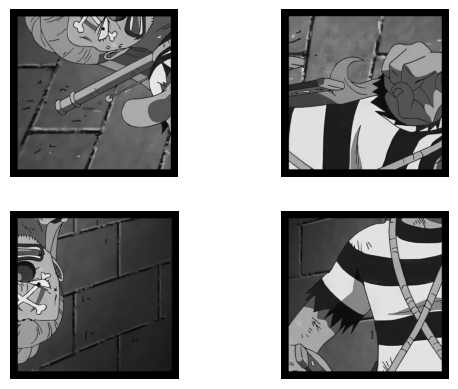

In [5]:
plt.subplot(2, 2, 1)
plt.imshow(gray_a, cmap = "gray")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gray_b, cmap = "gray")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gray_c, cmap = "gray")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gray_d, cmap = "gray")
plt.axis('off')

Baris code di bawah ini digunakan untuk melakukan operasi pencerminan (flip) pada citra grayscale secara manual, Proses ini dilakukan dengan membalik posisi piksel baik itu horizontal maupun vertikal pada array citra.dan digunakan untuk menampilkan empat buah gambar dalam satu kanvas menggunakan fungsi subplot dari matplotlib gambar hasil konversi ke dalam cerminan yang sudah di ubah ke grayscale sebelumnya.

In [6]:
def fungsi_empat_R(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0:
        return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w):
                rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

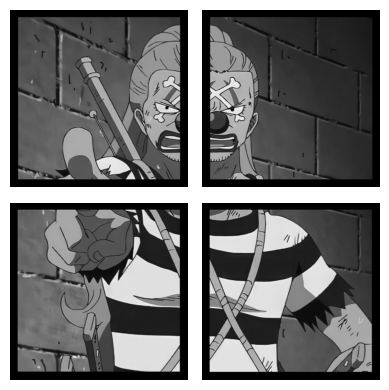

In [7]:
image_a_fixed = fungsi_empat_R(gray_a, 90) 

image_b_fixed = fungsi_empat_R(gray_b, 270)

image_c_fixed = fungsi_empat_R(gray_c, 180)
image_c_fixed = cv.flip(image_c_fixed, 1)

temp_d = fungsi_empat_R(gray_d, 0)
image_d_fixed = cv.flip(temp_d, 1)
images_fixed = [image_a_fixed, image_c_fixed, image_b_fixed, image_d_fixed]

plt.figure(figsize=(4, 4))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images_fixed[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
def fungsi_dilatasi(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape
    dilated = np.zeros((h * 2, w * 2), dtype=image.dtype)
    
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
            
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

Kode di bawah ini digunakan untuk menentukan range atau membuat gambar mebjadi besar sehingga menutupi garis hitam di pinggir. Kemudian menampilkan hasil dari proses yang sudah dilakukan menggunakan plt.imshow()

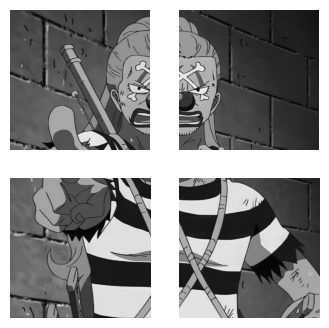

In [9]:
image_a_fixed = fungsi_dilatasi(image_a_fixed, p1=35, p2=35, p3=35, p4=35)
image_b_fixed = fungsi_dilatasi(image_b_fixed, p1=35, p2=35, p3=35, p4=35)
image_c_fixed = fungsi_dilatasi(image_c_fixed, p1=35, p2=35, p3=35, p4=35)
image_d_fixed = fungsi_dilatasi(image_d_fixed, p1=35, p2=35, p3=35, p4=35)

plt.figure(figsize=(4, 4))

plt.subplot(2, 2, 1)
plt.imshow(image_a_fixed, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(image_c_fixed, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(image_b_fixed, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(image_d_fixed, cmap='gray')
plt.axis('off')

plt.show()


In [10]:
def fungsi_dua_b(citra_1, citra_2):
    c1, c2 =np.array(citra_1), np.array(citra_2)
    tinggi = max(c1.shape[0], c2.shape[0])
    lebar = c1.shape[1] + c2.shape[1]
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[0:c1.shape[0], :c1.shape[1]] = c1
    hasil[0:c2.shape[0], c1.shape[1]:] = c2
    return hasil

def fungsi_dua_a(citra_1, citra_2):
    c1, c2 =np.array(citra_1), np.array(citra_2)
    tinggi = c1.shape[0] + c2.shape[0]
    lebar = max(c1.shape[1], c2.shape[1])
    hasil = np.zeros((tinggi, lebar), dtype=c1.dtype)
    hasil[:c1.shape[0], 0:c1.shape[1]] = c1
    hasil[c1.shape[0]:, 0:c2.shape[1]] = c2
    return hasil

(np.float64(-0.5), np.float64(1335.5), np.float64(667.5), np.float64(-0.5))

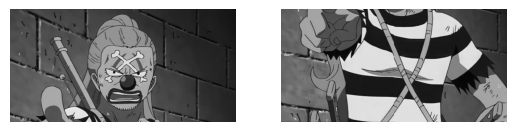

In [11]:
gabungatas = fungsi_dua_b(image_a_fixed, image_c_fixed)
gabungbawah = fungsi_dua_b(image_b_fixed, image_d_fixed)

plt.subplot(1, 2, 1)
plt.imshow(gabungatas, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gabungbawah, cmap='gray')
plt.axis('off')

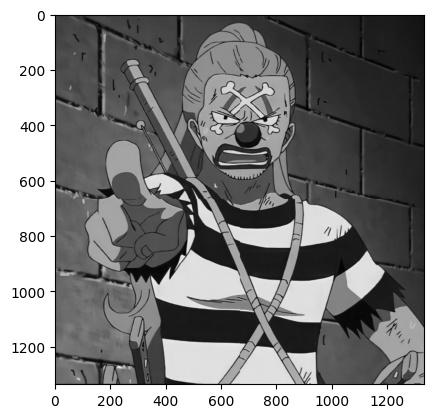

In [12]:
gabungan = fungsi_dua_a(gabungatas, gabungbawah)
plt.imshow(gabungan, cmap='gray')

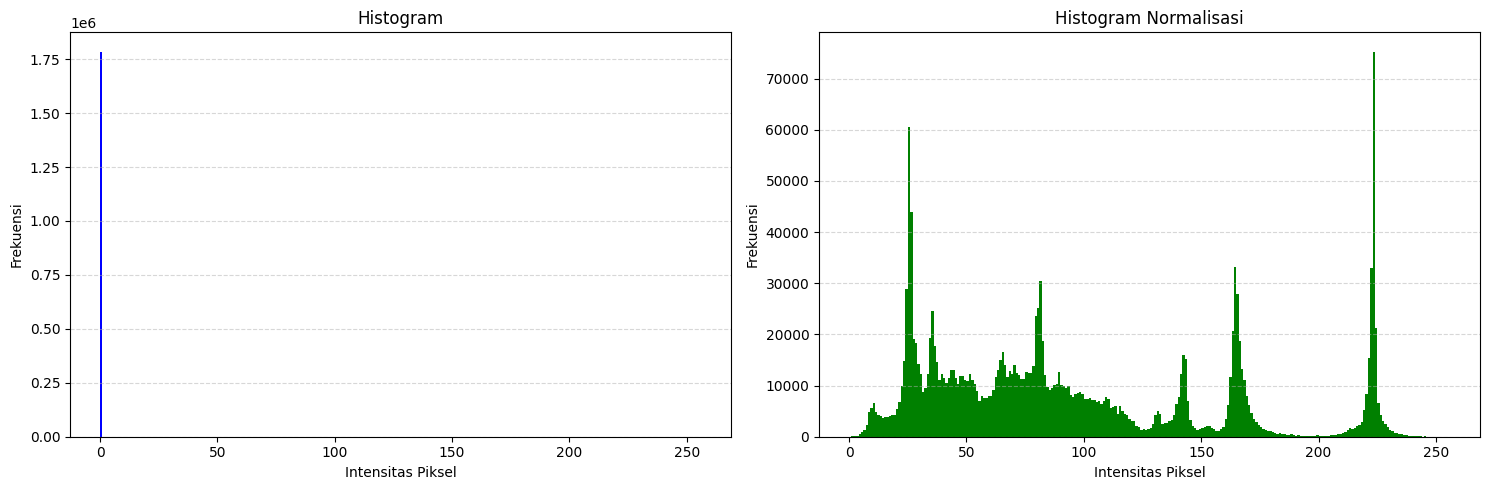

In [13]:
citra_asli = gabungan.astype(float)
c_min = np.min(citra_asli)
c_max = np.max(citra_asli)
citra_normalisasi = (citra_asli - c_min) * (255.0 / (c_max - c_min))
citra_normalisasi = citra_normalisasi.astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
data_biru = citra_asli.ravel()
plt.hist(data_biru[data_biru > 0], bins=256, range=(0, 256), color='blue', alpha=1.0)
plt.title("Histogram")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(citra_normalisasi.ravel(), bins=256, range=(0, 256), color='green', alpha=1.0)
plt.title("Histogram Normalisasi")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Frekuensi")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



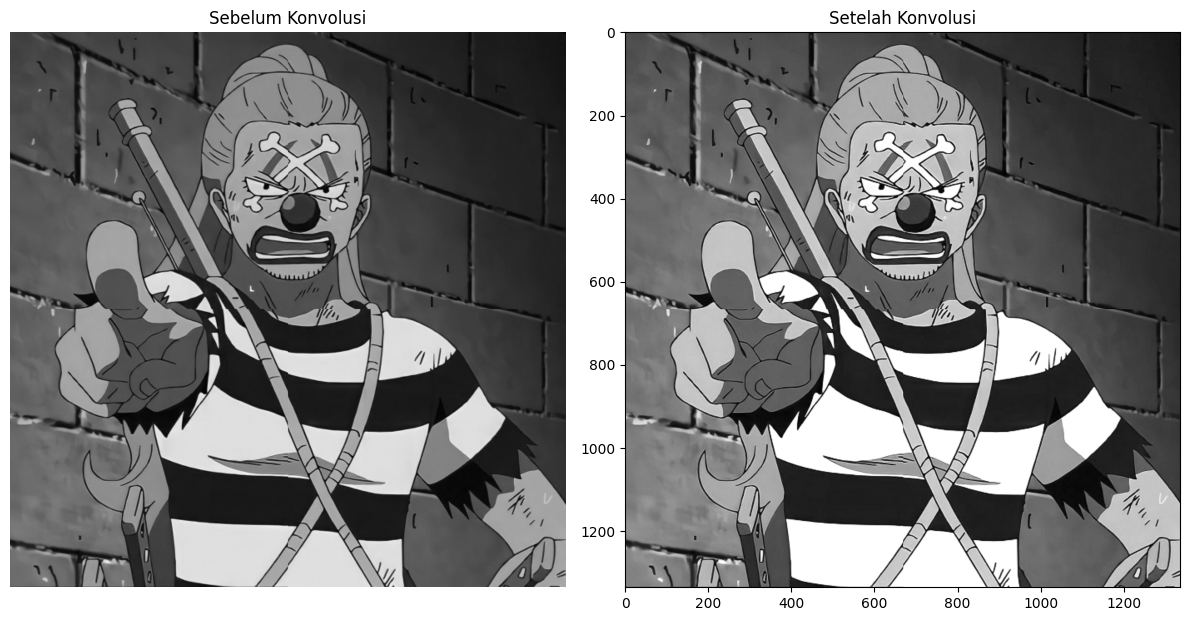

In [15]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

hasil_konvolusi = cv.filter2D(citra_normalisasi, -1, kernel)

# 3. Tampilkan Hasilnya
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(citra_normalisasi, cmap='gray')
plt.title("Sebelum Konvolusi")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil_konvolusi, cmap='gray')
plt.title("Setelah Konvolusi")
#plt.axis('off')

plt.tight_layout()
plt.show()